# Label
- 0: AML rất thấp
- 1: AML thấp
- 2: AML trung bình
- 3: AML cao
- 4: AML rất cao

In [1]:
import random
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# Hàm generate_aml_data_full_violation
org_violation_score_map = {
    "Tham nhũng chính trị / Can thiệp bầu cử": 3,
    "Tài trợ khủng bố": 6,
    "Vi phạm nhân quyền nghiêm trọng": 4,
    "Phát triển / sở hữu vũ khí hạt nhân trái phép": 6,
    "Xâm lược quốc gia khác": 6
}

categorical_features = [
    'residence_area', 'occupation',
    'per_violation_type_1', 'per_violation_type_2', 'per_violation_type_3', 'per_violation_type_4', 'per_violation_type_5',
    'per_legal_status_1', 'per_legal_status_2', 'per_legal_status_3', 'per_legal_status_4', 'per_legal_status_5',
    'per_role_1', 'per_role_2', 'per_role_3', 'per_role_4', 'per_role_5',
    'org_violation_type_1', 'org_violation_type_2', 'org_violation_type_3', 'org_violation_type_4', 'org_violation_type_5',
    'org_legal_status_1', 'org_legal_status_2', 'org_legal_status_3', 'org_legal_status_4', 'org_legal_status_5',
    'org_role_1', 'org_role_2', 'org_role_3', 'org_role_4', 'org_role_5'
]

residence_area = {
    'high': ["TP Hồ Chí Minh", "Hà Nội", "Hải Phòng", "Quảng Ninh", "Đà Nẵng",
             "Lạng Sơn", "Lào Cai", "Tây Ninh", "Kiên Giang", "Bình Dương",
             "Đồng Nai", "Cần Thơ", "An Giang", "Bà Rịa - Vũng Tàu"],
    'medium': ["Bình Thuận", "Bình Phước", "Bình Định", "Khánh Hòa", "Nghệ An",
               "Thanh Hóa", "Thừa Thiên Huế", "Đắk Lắk", "Đắk Nông", "Gia Lai",
               "Kon Tum", "Quảng Nam", "Quảng Ngãi", "Phú Yên", "Hà Tĩnh",
               "Hải Dương", "Nam Định", "Ninh Bình", "Thái Nguyên", "Vĩnh Phúc",
               "Long An", "Hậu Giang", "Tiền Giang", "Trà Vinh", "Vĩnh Long",
               "Sóc Trăng", "Cà Mau", "Bạc Liêu", "Bến Tre", "Phú Thọ",
               "Hưng Yên", "Thái Bình", "Ninh Thuận", "Hòa Bình", "Yên Bái",
               "Tuyên Quang", "Hà Nam", "Lâm Đồng", "Quảng Bình"],
    'low': ["Bắc Giang", "Bắc Kạn", "Bắc Ninh", "Cao Bằng", "Điện Biên",
            "Hà Giang", "Sơn La", "Lai Châu", "Quảng Trị", "Đồng Tháp"]
}

occupation = {
    'high': ["Cầm đồ", "Kinh doanh nhà hàng karaoke", "Chủ quán bar", "Làm từ thiện",
             "Tiếp viên quán", "Vũ công tự do", "Kinh doanh vàng bạc", "Chơi chứng khoán",
             "Doanh nhân", "Tự doanh", "Môi giới bất động sản", "Kinh doanh đa cấp", "Không rõ"],
    'medium': ["Luật sư", "Nhân viên ngân hàng", "Kế toán", "Kiểm toán viên",
               "Chuyên viên tài chính", "Tư vấn bảo hiểm", "Môi giới chứng khoán",
               "Tài xế giao dịch tiền", "Nhà báo", "Nghệ sĩ tự do", "Ca sĩ", "Diễn viên",
               "MC", "Freelancer", "Nhà văn", "Nhiếp ảnh gia", "Thiết kế đồ họa",
               "Chuyên gia SEO", "Quản trị fanpage", "Lái xe công nghệ", "Bán hàng online",
               "Chủ cửa hàng", "Lái taxi", "Chủ quán ăn", "Nhân viên marketing",
               "Cửa hàng trưởng", "Quản lý khách sạn", "Làm thuê thời vụ", "Trình dược viên",
               "Sinh viên", "Thất nghiệp", "Nội trợ", "Youtuber", "Tiktoker"],
    'low': ["Công an", "Bộ đội", "Thẩm phán", "Kiểm sát viên", "Giảng viên đại học",
            "Giáo viên phổ thông", "Gia sư", "Nhà khoa học", "Kỹ sư phần mềm", "Lập trình viên",
            "Kỹ sư xây dựng", "Kỹ sư điện", "Kỹ thuật viên phòng lab", "Chuyên viên CNTT",
            "Phân tích dữ liệu", "Bác sĩ", "Y tá", "Dược sĩ", "Bác sĩ thú y",
            "Nhân viên chăm sóc sắc đẹp", "Chuyên viên spa", "Chăm sóc người già", "Công nhân",
            "Thợ xây", "Thợ điện", "Thợ nước", "Thợ mộc", "Thợ hàn", "Lái xe tải", "Bốc vác",
            "Bảo vệ", "Nhân viên bảo trì", "Nhân viên bán hàng", "Nhân viên phục vụ", "Lễ tân",
            "Nhân viên thu ngân", "Tư vấn tuyển sinh", "Học sinh"]
}

def get_label(score):
    if score >= 15:
        return 4
    elif score >= 11:
        return 3
    elif score >= 7:
        return 2
    elif score >= 4:
        return 1
    else:
        return 0

def calculate_score(per_violation_score, per_role_score, per_legal, org_violation, org_legal, age, area, job):
    score = 0
    reasons = []
    if per_legal == "Minh oan":
        reasons.append("Được minh oan (reset vi phạm và vai trò)")
    else:
        if per_violation_score > 0:
            score += per_violation_score
            reasons.append(f"Vi phạm: +{per_violation_score}")
        if per_role_score > 0:
            adjusted_role_score = 5 if per_role_score == 6 else 3 if per_role_score == 4 else 1 if per_role_score == 2 else 0
            score += adjusted_role_score
            reasons.append(f"Vai trò: +{adjusted_role_score}")
        if per_legal == "Đã kết án":
            score += 3; reasons.append("Đã kết án (+3)")
        elif per_legal in ["Đang điều tra", "Truy tố"]:
            score += 2; reasons.append("Đang điều tra/truy tố (+2)")
        elif per_legal == "Chưa rõ":
            score += 1; reasons.append("Pháp lý chưa rõ (+1)")
    if org_violation:
        if org_violation in org_violation_score_map:
            score_add = org_violation_score_map[org_violation]
            score += score_add
            reasons.append(f"Tổ chức vi phạm: {org_violation} (+{score_add})")
    if org_legal == "Đã kết án":
        score += 3; reasons.append("Tổ chức đã kết án (+3)")
    elif org_legal in ["Đang điều tra", "Truy tố"]:
        score += 2; reasons.append("Tổ chức bị điều tra/truy tố (+2)")
    if age < 30:
        score += 2; reasons.append("Tuổi < 30 (+2)")
    elif age > 65:
        score += 0.5; reasons.append("Tuổi > 65 (+0.5)")
    if area in residence_area['high']:
        score += 1.5; reasons.append("Khu vực rủi ro cao (+1.5)")
    elif area in residence_area['medium']:
        score += 0.5; reasons.append("Khu vực rủi ro vừa (+0.5)")
    if job in occupation['high']:
        score += 2; reasons.append("Nghề rủi ro cao (+2)")
    elif job in occupation['medium']:
        score += 0.5; reasons.append("Nghề rủi ro vừa (+0.5)")
    return score, reasons

def generate_aml_data_full_violation(n_samples=1000, train_ratio=0.8, seed=2025):
    random.seed(seed)
    train_samples = []
    test_samples = []
    unique_samples = set()
    area_list = [loc for sub in residence_area.values() for loc in sub]
    job_list = [job for sub in occupation.values() for job in sub]
    violation_type_pool = {
        6: ["Rửa tiền", "Tài trợ khủng bố"],
        4: ["Lừa đảo", "Chiếm đoạt tài sản", "Tham nhũng", "Hối lộ"],
        2: ["Vi phạm hành chính", "Tranh chấp dân sự", "Vi phạm dân sự", "Vi phạm nhỏ"],
        0: ["None"]  # Thay None bằng chuỗi "None"
    }
    legal_pool = ["Đã kết án", "Đang điều tra", "Truy tố", "Chưa rõ", "Minh oan", "None"]
    role_pool = {
        6: ["Chủ mưu", "Cầm đầu", "Tổ chức thực hiện"],
        4: ["Tham gia", "Giúp sức", "Đồng phạm"],
        2: ["Bị nhắc tên", "Liên quan bị động"],
        0: ["None"]
    }
    org_violation_pool = list(org_violation_score_map.keys()) + ["None"]
    org_legal_pool = ["Đã kết án", "Đang điều tra", "Truy tố", "None"]
    org_role_pool = {
        6: ["Chủ mưu", "Cầm đầu", "Tổ chức thực hiện"],
        4: ["Tham gia", "Giúp sức", "Đồng phạm"],
        2: ["Bị nhắc tên", "Liên quan bị động"],
        0: ["None"]
    }
    max_violation = 5
    target_distribution = {
        4: int(n_samples * 0.05),
        3: int(n_samples * 0.10),
        2: int(n_samples * 0.20),
        1: int(n_samples * 0.30),
        0: int(n_samples * 0.35)
    }
    train_target = {k: int(v * train_ratio) for k, v in target_distribution.items()}
    test_target = {k: v - train_target[k] for k, v in target_distribution.items()}
    train_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
    test_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
    non_null_sample_count = 0

    for _ in range(n_samples * 15):
        area = random.choice(area_list)
        job = random.choice(job_list)
        age = int(random.randint(18, 75))
        if area is None or job is None or age is None:
            continue

        per_violation_count = random.choices([1, 2, 3, 4, 5], weights=[0.7, 0.18, 0.07, 0.03, 0.02])[0]
        per_violation_scores = random.choices([6, 4, 2, 0], weights=[0.1, 0.15, 0.3, 0.45], k=per_violation_count)
        per_violation_types = []
        used_types = set()
        for score in per_violation_scores:
            candidates = [x for x in violation_type_pool[score] if x not in used_types]
            vtype = random.choice(candidates) if candidates else "None"
            per_violation_types.append(vtype)
            if vtype != "None": used_types.add(vtype)
        while len(per_violation_types) < max_violation:
            per_violation_types.append("None")

        per_roles = []
        for i in range(max_violation):
            vtype = per_violation_types[i]
            if vtype != "None":
                score = per_violation_scores[i] if i < len(per_violation_scores) else 0
                if score > 0:
                    possible_roles = role_pool[score]
                    role = random.choice(possible_roles)
                else:
                    role = "None"
            else:
                role = "None"
            per_roles.append(role)

        per_legal_statuses = [
            random.choices(
                legal_pool,
                weights=[0.03, 0.05, 0.04, 0.1, 0.01, 0.77]
            )[0] if vtype != "None" else "None"
            for vtype in per_violation_types
        ]
        per_violation_score = per_violation_scores[0]
        per_violation = per_violation_types[0]
        per_role_score = 0
        if per_violation_score > 0:
            per_role_score = 6 if per_roles[0] in role_pool[6] else 4 if per_roles[0] in role_pool[4] else 2 if per_roles[0] in role_pool[2] else 0
        per_legal = per_legal_statuses[0]

        org_violation_count = random.choices([0, 1, 2, 3, 4, 5], weights=[0.55, 0.25, 0.10, 0.06, 0.03, 0.01])[0]
        org_violation_types = []
        used_org_types = set()
        for _ in range(org_violation_count):
            candidates = [x for x in org_violation_pool if x not in used_org_types]
            vtype = random.choice(candidates) if candidates else "None"
            org_violation_types.append(vtype)
            if vtype != "None": used_org_types.add(vtype)
        while len(org_violation_types) < max_violation:
            org_violation_types.append("None")
        org_roles = []
        for i in range(max_violation):
            vtype = org_violation_types[i]
            if vtype != "None":
                score = random.choices([6, 4, 2], weights=[0.3, 0.5, 0.2])[0]
                role = random.choice(org_role_pool[score])
            else:
                role = "None"
            org_roles.append(role)
        org_legal_statuses = [
            random.choice(org_legal_pool) if vtype != "None" else "None"
            for vtype in org_violation_types
        ]
        org_violation = org_violation_types[0]
        org_legal = org_legal_statuses[0]
        score, reasons = calculate_score(
            per_violation_score, per_role_score, per_legal,
            org_violation, org_legal, age, area, job
        )
        label = get_label(score)

        is_train = random.random() < train_ratio
        if is_train and train_counts[label] >= train_target[label]:
            continue
        elif not is_train and test_counts[label] >= test_target[label]:
            continue

        is_non_null = any([
            per_violation_score > 0,
            per_role_score > 0,
            per_legal not in ("", "None"),
            org_violation not in ("", "None"),
            org_legal not in ("", "None")
        ])
        if not is_non_null and non_null_sample_count < int(n_samples * 0.7):
            continue
        elif is_non_null:
            non_null_sample_count += 1

        row = {
            "residence_area": area,
            "occupation": job,
            "age": age,
            "total_score": score,
            "label": label,
            "risk_reason": "; ".join(reasons)
        }
        for i in range(max_violation):
            row[f"per_violation_type_{i+1}"] = per_violation_types[i]
            row[f"per_legal_status_{i+1}"] = per_legal_statuses[i]
            row[f"per_role_{i+1}"] = per_roles[i]
        for i in range(max_violation):
            row[f"org_violation_type_{i+1}"] = org_violation_types[i]
            row[f"org_legal_status_{i+1}"] = org_legal_statuses[i]
            row[f"org_role_{i+1}"] = org_roles[i]

        sample_tuple = tuple(row.values())
        if sample_tuple in unique_samples:
            continue
        unique_samples.add(sample_tuple)

        if is_train:
            train_samples.append(row)
            train_counts[label] += 1
        else:
            test_samples.append(row)
            test_counts[label] += 1

        if len(train_samples) + len(test_samples) >= n_samples:
            break

    train_df = pd.DataFrame(train_samples)
    test_df = pd.DataFrame(test_samples)

    for df in [train_df, test_df]:
        if not df.empty:
            assert df['residence_area'].isnull().sum() == 0
            assert df['occupation'].isnull().sum() == 0
            assert df['age'].isnull().sum() == 0
            # Thay thế None trong cột phân loại bằng "None"
            for col in df.columns:
                if col in categorical_features:
                    df[col] = df[col].fillna("None").astype(str)

    return train_df, test_df

# Tạo dữ liệu
train_df, test_df = generate_aml_data_full_violation(n_samples=1000, train_ratio=0.8, seed=2025)

In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)

# pd.set_option('display.max_rows', None)

pd.set_option('display.expand_frame_repr', False)

pd.set_option('display.width', 200)

train_df.head(10)

,residence_area,occupation,age,total_score,label,risk_reason,per_violation_type_1,per_legal_status_1,per_role_1,per_violation_type_2,per_legal_status_2,per_role_2,per_violation_type_3,per_legal_status_3,per_role_3,per_violation_type_4,per_legal_status_4,per_role_4,per_violation_type_5,per_legal_status_5,per_role_5,org_violation_type_1,org_legal_status_1,org_role_1,org_violation_type_2,org_legal_status_2,org_role_2,org_violation_type_3,org_legal_status_3,org_role_3,org_violation_type_4,org_legal_status_4,org_role_4,org_violation_type_5,org_legal_status_5,org_role_5
0,Lai Châu,Lễ tân,43,3.0,0,Vi phạm: +2; Vai trò: +1,Tranh chấp dân sự,None,Bị nhắc tên,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,Đồng Tháp,Công an,23,13.0,3,Vi phạm: +2; Vai trò: +1; Tổ chức vi phạm: Xâm...,Vi phạm dân sự,None,Bị nhắc tên,Vi phạm nhỏ,None,Liên quan bị động,None,None,None,None,None,None,None,None,None,Xâm lược quốc gia khác,Đang điều tra,Liên quan bị động,None,None,None,None,None,None,None,None,None,None,None,None
2,Vĩnh Long,Quản lý khách sạn,28,11.0,3,Tổ chức vi phạm: Tài trợ khủng bố (+6); Tổ chứ...,None,None,None,Tranh chấp dân sự,None,Liên quan bị động,None,None,None,None,None,None,None,None,None,Tài trợ khủng bố,Đang điều tra,Tổ chức thực hiện,None,None,None,None,None,None,None,None,None,None,None,None
3,Kon Tum,Thất nghiệp,50,9.0,2,Tổ chức vi phạm: Tài trợ khủng bố (+6); Tổ chứ...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Tài trợ khủng bố,Đang điều tra,Chủ mưu,None,None,None,None,None,None,None,None,None,None,None,None
4,Bắc Kạn,Thợ mộc,66,4.5,1,Vi phạm: +2; Vai trò: +1; Pháp lý chưa rõ (+1)...,Vi phạm hành chính,Chưa rõ,Liên quan bị động,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
5,Bình Thuận,Bảo vệ,66,8.0,2,Vi phạm: +4; Vai trò: +3; Tuổi > 65 (+0.5); Kh...,Chiếm đoạt tài sản,None,Tham gia,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
6,Bắc Ninh,Tư vấn tuyển sinh,55,11.0,3,Vi phạm: +6; Vai trò: +5,Tài trợ khủng bố,None,Tổ chức thực hiện,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
7,Bắc Giang,Nhân viên bảo trì,21,19.0,4,Vi phạm: +6; Vai trò: +5; Tổ chức vi phạm: Tài...,Tài trợ khủng bố,None,Chủ mưu,None,None,None,None,None,None,None,None,None,None,None,None,Tài trợ khủng bố,None,Đồng phạm,None,None,None,None,None,None,None,None,None,None,None,None
8,Phú Yên,Chủ quán ăn,53,4.0,1,Vi phạm: +2; Vai trò: +1; Khu vực rủi ro vừa (...,Vi phạm dân sự,None,Liên quan bị động,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
9,Ninh Bình,Cầm đồ,64,8.5,2,Vi phạm: +2; Vai trò: +1; Đã kết án (+3); Khu ...,Vi phạm dân sự,Đã kết án,Bị nhắc tên,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [3]:
columns_order = [
    "residence_area", "occupation", "age",
    "per_violation_type_1", "per_legal_status_1", "per_role_1",
    "per_violation_type_2", "per_legal_status_2", "per_role_2",
    "per_violation_type_3", "per_legal_status_3", "per_role_3",
    "per_violation_type_4", "per_legal_status_4", "per_role_4",
    "per_violation_type_5", "per_legal_status_5", "per_role_5",
    "org_violation_type_1", "org_legal_status_1", "org_role_1",
    "org_violation_type_2", "org_legal_status_2", "org_role_2",
    "org_violation_type_3", "org_legal_status_3", "org_role_3",
    "org_violation_type_4", "org_legal_status_4", "org_role_4",
    "org_violation_type_5", "org_legal_status_5", "org_role_5"
]

# Nếu còn các cột khác như "total_score", "label", "risk_reason", bạn có thể thêm sau cùng nếu cần
columns_order += ["total_score", "label", "risk_reason"]

# Sắp xếp lại thứ tự cột trong DataFrame
train_df = train_df[columns_order]
test_df = test_df[columns_order]

In [4]:
# In phân bố nhãn
print("Train label distribution:")
print(train_df['label'].value_counts(normalize=True).sort_index())
print("\nTest label distribution:")
print(test_df['label'].value_counts(normalize=True).sort_index())

Train label distribution:
label
0    0.35
1    0.30
2    0.20
3    0.10
4    0.05
Name: proportion, dtype: float64

Test label distribution:
label
0    0.35
1    0.30
2    0.20
3    0.10
4    0.05
Name: proportion, dtype: float64


0:	learn: 1.4392998	total: 215ms	remaining: 3m 34s
100:	learn: 0.3957455	total: 10.9s	remaining: 1m 37s
200:	learn: 0.2806340	total: 21.9s	remaining: 1m 27s
300:	learn: 0.2162373	total: 32.7s	remaining: 1m 15s
400:	learn: 0.1653063	total: 43.2s	remaining: 1m 4s
500:	learn: 0.1335555	total: 54.6s	remaining: 54.3s
600:	learn: 0.1083689	total: 1m 5s	remaining: 43.2s
700:	learn: 0.0904956	total: 1m 15s	remaining: 32.2s
800:	learn: 0.0777967	total: 1m 26s	remaining: 21.6s
900:	learn: 0.0672768	total: 1m 37s	remaining: 10.7s
999:	learn: 0.0585871	total: 1m 48s	remaining: 0us

Model Evaluation:
Accuracy: 0.8400
Precision: 0.8503
Recall: 0.8400
F1-Score: 0.8413

Confusion Matrix:
[[57 13  0  0  0]
 [ 4 51  5  0  0]
 [ 0  4 36  0  0]
 [ 0  0  3 15  2]
 [ 0  0  0  1  9]]


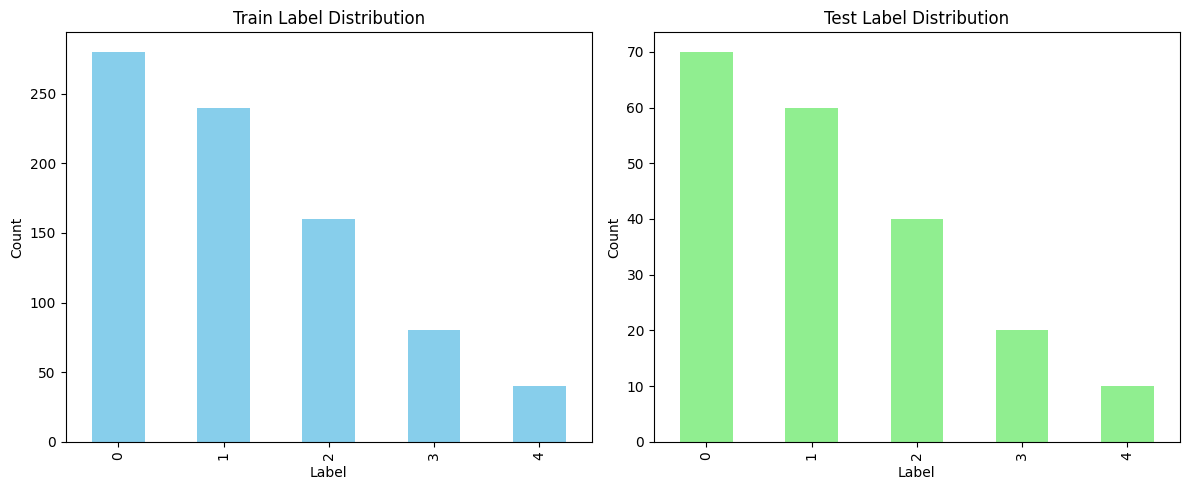

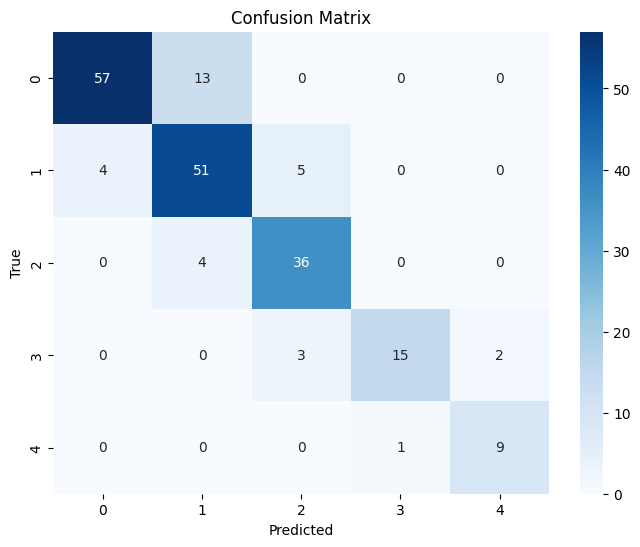

In [5]:
# Chuẩn bị dữ liệu cho CatBoost
features = [col for col in train_df.columns if col not in ['label', 'total_score', 'risk_reason']]
X_train = train_df[features]
y_train = train_df['label']
X_test = test_df[features]
y_test = test_df['label']

# Xác định các cột phân loại
categorical_features = [
    'residence_area', 'occupation',
    'per_violation_type_1', 'per_violation_type_2', 'per_violation_type_3', 'per_violation_type_4', 'per_violation_type_5',
    'per_legal_status_1', 'per_legal_status_2', 'per_legal_status_3', 'per_legal_status_4', 'per_legal_status_5',
    'per_role_1', 'per_role_2', 'per_role_3', 'per_role_4', 'per_role_5',
    'org_violation_type_1', 'org_violation_type_2', 'org_violation_type_3', 'org_violation_type_4', 'org_violation_type_5',
    'org_legal_status_1', 'org_legal_status_2', 'org_legal_status_3', 'org_legal_status_4', 'org_legal_status_5',
    'org_role_1', 'org_role_2', 'org_role_3', 'org_role_4', 'org_role_5'
]

# Tạo Pool cho CatBoost
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
test_pool = Pool(X_test, y_test, cat_features=categorical_features)

# Khởi tạo và huấn luyện mô hình CatBoost
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=100,
    random_seed=2025
)
model.fit(train_pool)

# Đánh giá mô hình
y_pred = model.predict(test_pool)
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Vẽ biểu đồ phân bố nhãn
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
train_df['label'].value_counts().sort_index().plot(kind='bar', title='Train Label Distribution', color='skyblue')
plt.xlabel('Label')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
test_df['label'].value_counts().sort_index().plot(kind='bar', title='Test Label Distribution', color='lightgreen')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [6]:
import joblib
joblib.dump(model, 'catboost_aml_model.pkl')

['catboost_aml_model.pkl']

In [7]:
import joblib
model = joblib.load('catboost_aml_model.pkl')

# Inference

In [8]:
sample = {
    "residence_area": "TP Hồ Chí Minh",
    "occupation": "Thẩm phán",
    "age": 35,
    
    "per_violation_type_1": "Lừa đảo",
    "per_legal_status_1": None,
    "per_role_1": "Đồng phạm",

    "per_violation_type_2": None,
    "per_legal_status_2": None,
    "per_role_2": None,

    "per_violation_type_3": None,
    "per_legal_status_3": None,
    "per_role_3": None,

    "per_violation_type_4": None,
    "per_legal_status_4": None,
    "per_role_4": None,

    "per_violation_type_5": None,
    "per_legal_status_5": None,
    "per_role_5": None,

    "org_violation_type_1": None,
    "org_legal_status_1": None,
    "org_role_1": None,

    "org_violation_type_2": None,
    "org_legal_status_2": None,
    "org_role_2": None,

    "org_violation_type_3": None,
    "org_legal_status_3": None,
    "org_role_3": None,

    "org_violation_type_4": None,
    "org_legal_status_4": None,
    "org_role_4": None,

    "org_violation_type_5": None,
    "org_legal_status_5": None,
    "org_role_5": None
}

import pandas as pd
for k, v in sample.items():
    if v is None:
        sample[k] = "None"

sample_df = pd.DataFrame([sample])

In [9]:
sample_pred = model.predict(sample_df)
print("Label dự đoán cho sample:", int(sample_pred[0]))

Label dự đoán cho sample: 2


/tmp/ipykernel_19/108674422.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Label dự đoán cho sample:", int(sample_pred[0]))
